<a href="https://colab.research.google.com/github/Lilli-Ai/langgraph-receipt-splitter/blob/main/receipt_splitter_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Receipt Splitter Agent (LangGraph)

In [2]:
!pip install -q -U langgraph langchain-google-genai datasets

**Data source:** CORD v2 dataset by NAVER CLOVA (Hugging Face)
https://huggingface.co/datasets/naver-clova-ix/cord-v2
Real restaurant receipts, license CC BY 4.0

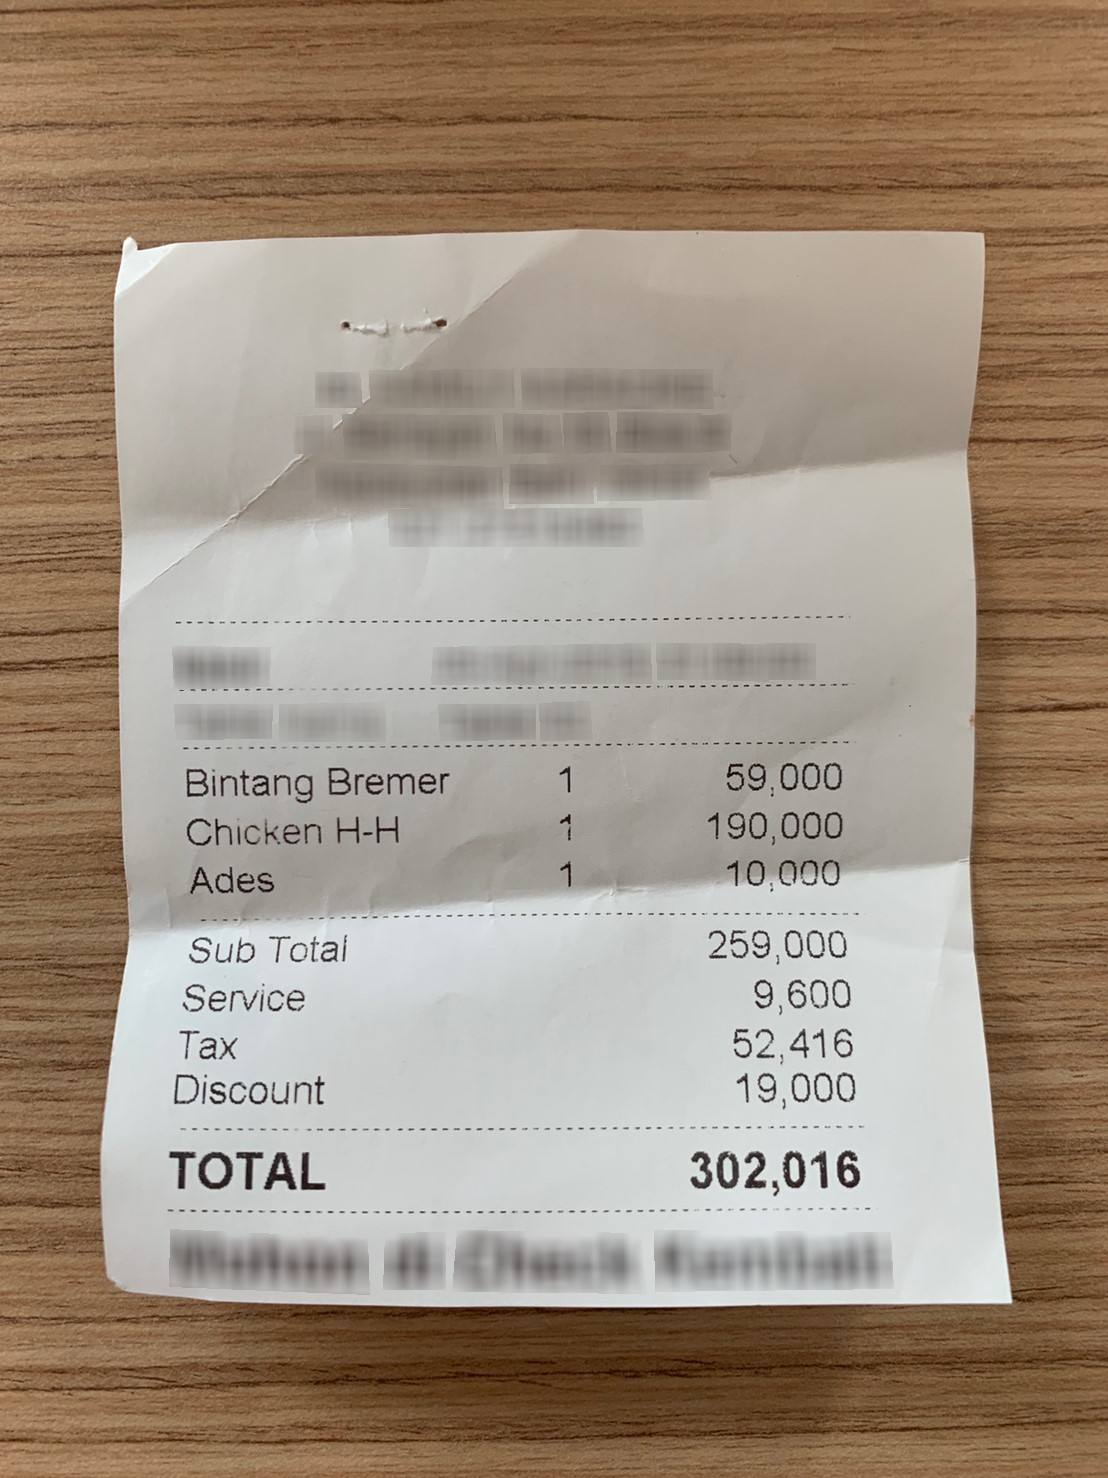

In [1]:
from datasets import load_dataset

# открываем датасет в режиме streaming — не качаем все 2.3 GB
ds = load_dataset("naver-clova-ix/cord-v2", split="train", streaming=True)

# идём по чекам и берём чек №3
for i, row in enumerate(ds):
    if i == 3:
        receipt = row
        break

img = receipt["image"]      # картинка чека
img.save("receipt.jpg")     # сохраняем файлом — агенту нужен путь к файлу
display(img)                # показываем чек на экране

In [2]:
from google.colab import userdata
import os

# берём ключи из Secrets и кладём в "окружение", где их найдут библиотеки
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# проверяем, что ключи есть — сами ключи НЕ печатаем
print("GOOGLE_API_KEY loaded:", bool(os.environ["GOOGLE_API_KEY"]))
print("HF_TOKEN loaded:", bool(os.environ["HF_TOKEN"]))

GOOGLE_API_KEY loaded: True
HF_TOKEN loaded: True


In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI

# создаём LLM — ключ GOOGLE_API_KEY библиотека возьмёт сама из окружения
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

# тестовый вопрос
response = llm.invoke("Say hello in one short sentence.")
print(response.text)

Hello, nice to meet you!


In [6]:
import base64
from langchain_core.messages import HumanMessage

def extract_text(img_path: str) -> str:
    """
    Extract all text from a receipt image using a multimodal model.

    Args:
        img_path: A local image file path (string).

    Returns:
        The extracted text from the image.
    """
    try:
        # читаем картинку и превращаем её в base64-текст
        with open(img_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode("utf-8")

        # сообщение модели: инструкция + сама картинка
        message = [
            HumanMessage(
                content=[
                    {"type": "text",
                     "text": "Extract all the text from this receipt image. Return only the extracted text, no explanations."},
                    {"type": "image_url",
                     "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                ]
            )
        ]

        response = llm.invoke(message)
        return response.text.strip()

    except Exception as e:
        print(f"Error extracting text: {e}")
        return ""

# проверка на нашем чеке
print(extract_text("receipt.jpg"))

Bintang Bremer 1 59,000
Chicken H-H 1 190,000
Ades 1 10,000
Sub Total 259,000
Service 9,600
Tax 52,416
Discount 19,000
TOTAL 302,016


In [9]:
def multiply(a: float, b: float) -> float:
    """Multiply a and b."""
    return round(a * b, 2)


def divide(a: float, b: float) -> float:
    """Divide a by b."""
    return round(a / b, 2)


def split_bill(total: float, people: int, tip_percent: float = 0) -> float:
    """
    Split a bill between people, optionally adding a tip.

    Args:
        total: The total amount of the bill.
        people: Number of people sharing the bill.
        tip_percent: Tip in percent (e.g. 10 for 10%). Default 0.

    Returns:
        The amount each person should pay.
    """
    total_with_tip = total * (1 + tip_percent / 100)
    return round(total_with_tip / people, 2)


# проверка без агента
print(multiply(302016, 0.1))     # 10% от счёта
print(divide(302016, 3))         # делим на 3
print(split_bill(302016, 3, 10)) # на 3 человек + 10% чаевых

30201.6
100672.0
110739.2


In [16]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 1. список всех tools агента
tools = [extract_text, multiply, divide, split_bill]

# 2. "привязываем" tools к модели
llm_with_tools = llm.bind_tools(tools)

# 3. State — общая память агента, которая передаётся между шагами графа
class AgentState(TypedDict):
    input_file: Optional[str]                              # путь к картинке чека
    messages: Annotated[list[AnyMessage], add_messages]    # история сообщений

print("Tools:", [t.__name__ for t in tools])

Tools: ['extract_text', 'multiply', 'divide', 'split_bill']


In [11]:
from langchain_core.messages import SystemMessage

def assistant(state: AgentState):
    image = state["input_file"]

    # инструкция для агента (system prompt)
    sys_msg = SystemMessage(content=f"""
You are a helpful Receipt Splitter assistant.

Rules:
- If a receipt image is provided, first use the extract_text tool to read it.
- Always use the math tools (multiply, divide, split_bill) for calculations. Never calculate in your head.
- Amounts are in Indonesian Rupiah (IDR). Numbers like "59,000" mean 59000.
- Use the TOTAL from the receipt unless the user asks otherwise.
- Answer shortly and clearly: show the total, the tip (if any), and how much each person pays.

Currently loaded receipt image: {image}
""")

    # отправляем модели инструкцию + всю историю сообщений
    response = llm_with_tools.invoke([sys_msg] + state["messages"])

    return {"messages": [response], "input_file": state["input_file"]}

print("assistant node ready")

assistant node ready


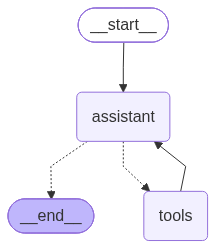

In [12]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# 1. создаём граф с нашей памятью (State)
builder = StateGraph(AgentState)

# 2. добавляем nodes (шаги)
builder.add_node("assistant", assistant)       # думает и решает
builder.add_node("tools", ToolNode(tools))     # запускает tools

# 3. добавляем edges (стрелки)
builder.add_edge(START, "assistant")           # начинаем с assistant
builder.add_conditional_edges("assistant", tools_condition)  # развилка
builder.add_edge("tools", "assistant")         # после tool — обратно думать

# 4. компилируем граф
react_graph = builder.compile()

# 5. рисуем схему
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [17]:
question = "We are 3 people and want to leave a 10% tip. How much should each person pay?"

result = react_graph.invoke({
    "messages": [HumanMessage(content=question)],
    "input_file": "receipt.jpg",
})

# печатаем весь ход рассуждений агента
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

We are 3 people and want to leave a 10% tip. How much should each person pay?
================================== Ai Message ==================================

[]
Tool Calls:
  extract_text (call_65127)
 Call ID: call_65127
  Args:
    img_path: receipt.jpg
================================= Tool Message =================================
Name: extract_text

Bintang Bremer 1 59,000
Chicken H-H 1 190,000
Ades 1 10,000
Sub Total 259,000
Service 9,600
Tax 52,416
Discount 19,000
TOTAL 302,016
================================== Ai Message ==================================

[]
Tool Calls:
  split_bill (call_653719)
 Call ID: call_653719
  Args:
    tip_percent: 10
    people: 3
    total: 302016
================================= Tool Message =================================
Name: split_bill

110739.2
================================== Ai Message ==================================

[{'type': 'text', 'text': '- *

In [18]:
print(result["messages"][-1].text)

- **Total:** IDR 302,016
- **Tip (10%):** IDR 30,201.60
- **Each person pays (3 people):** IDR 110,739.20
